In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
data=pd.read_csv('spam.csv',encoding='latin1')

In [3]:
data.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
776,ham,Why don't you go tell your friend you're not s...,NaN,NaN,NaN
4843,spam,YOU HAVE WON! As a valued Vodafone customer ou...,NaN,NaN,NaN
3279,ham,Badrith is only for chennai:)i will surely pic...,NaN,NaN,NaN
2939,spam,You have 1 new message. Please call 08712400200.,NaN,NaN,NaN
4230,ham,U really pig leh sleep so much. My dad wake me...,NaN,NaN,NaN


In [4]:
data.shape

(5572, 5)

In [5]:
# the process which i can do
# data cleaning
#EDA
#Data preprocessing
# Model bulding 
# Evalustion
# improvement 
# webside production

# Data Cleaning

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
data.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [8]:
data.shape

(5572, 2)

In [9]:
data.sample(4)

,v1,v2
1134,ham,U wake up already? Thanx 4 e tau sar piah it's...
1631,ham,We not watching movie already. Xy wants 2 shop...
923,ham,She went to attend another two rounds today..b...
4476,ham,Oh :-)only 4 outside players allowed to play know


In [10]:
# rename the columns name
data.rename(columns={"v1":"Target","v2":"Mails"},inplace=True)

In [11]:
data.head()

,Target,Mails
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
# applying labelencoder target
from sklearn.preprocessing import LabelEncoder
LE=LabelEncoder()

In [13]:
data['Target']=LE.fit_transform(data['Target'])

In [14]:
data .shape

(5572, 2)

In [15]:
data.head(5)

,Target,Mails
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
# checking for missing values
data.isnull().sum()

Target    0
Mails     0
dtype: int64

In [17]:
# checking for duplicate values
data.duplicated().sum()

403

In [18]:
# Remove the duplicarte values
data=data.drop_duplicates(keep='first')


In [19]:
data.duplicated().sum()

0

In [20]:
data.shape

(5169, 2)

# EDA 

In [21]:
data.head()

,Target,Mails
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [22]:
data["Target"].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

In [23]:
import matplotlib.pyplot as plt

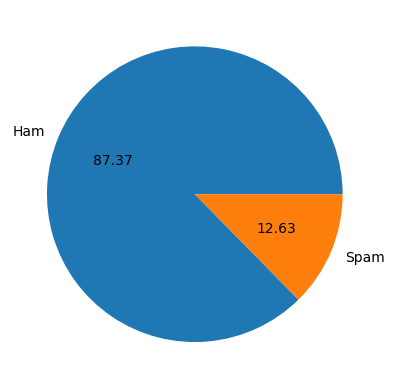

the Data is highly imbalance


In [24]:
plt.pie(data["Target"].value_counts(),labels=['Ham','Spam'],autopct='%0.2f')
plt.show()
print("the Data is highly imbalance")

In [25]:
# to remove the 
import nltk

In [26]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\SmarT
[nltk_data]     TecH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [27]:
#To find number of charactor
data['num_charactor']=data['Mails'].apply(len)

In [28]:
data.head()

,Target,Mails,num_charactor
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [29]:
# To find number of words
data['num_word']=data['Mails'].apply(lambda x:len(nltk.word_tokenize(x)))

In [30]:
data.head()

,Target,Mails,num_charactor,num_word
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [31]:
# To find number of sentence 
data['num_sentence']=data['Mails'].apply(lambda x:len(nltk.sent_tokenize(x)))


In [32]:
data.head()

,Target,Mails,num_charactor,num_word,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [33]:
data[['num_charactor','num_word','num_sentence']].describe()

,num_charactor,num_word,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [34]:
# for Ham
data[data['Target']==0][['num_charactor','num_word','num_sentence']].describe()

,num_charactor,num_word,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [35]:
# for spam
data[data['Target']==1][['num_charactor','num_word','num_sentence']].describe()

,num_charactor,num_word,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [36]:
import seaborn as sns 

In [37]:
import warnings
warnings.filterwarnings('ignore')

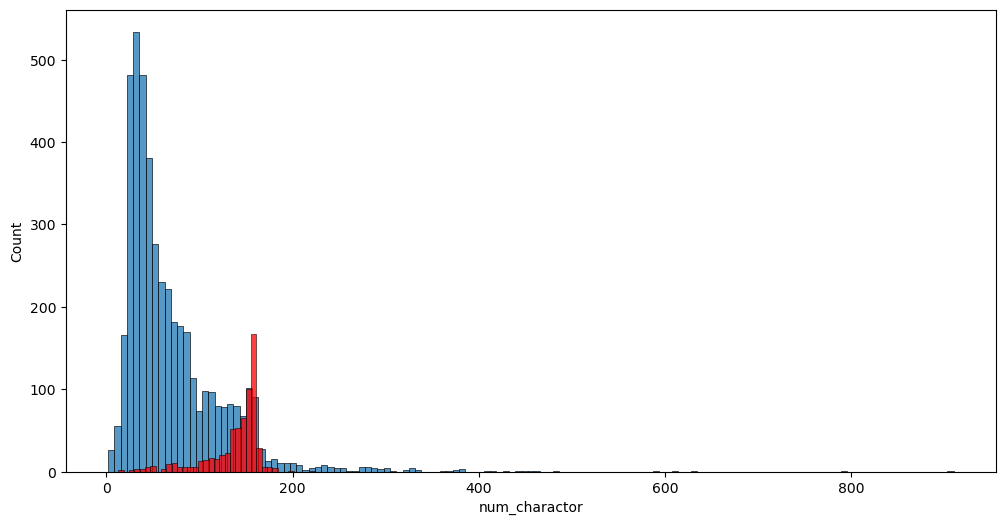

the num_charactor in spam is greater then  the ham after observation 


In [38]:
plt.figure(figsize=(12,6))
sns.histplot(data[data['Target']==0]['num_charactor'])
sns.histplot(data[data['Target']==1]['num_charactor'],color='red')
plt.show()
print('the num_charactor in spam is greater then  the ham after observation ')

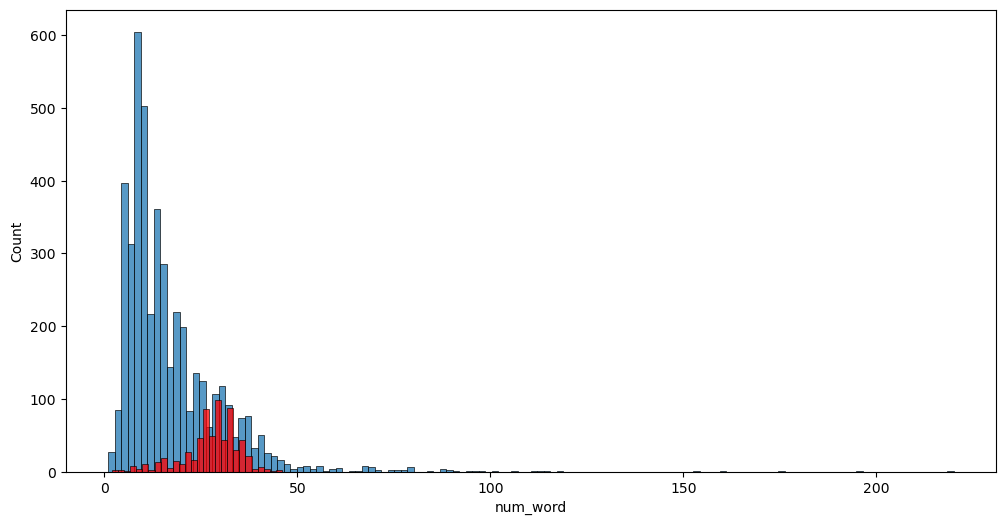

the num_word in spam is greater then  the ham after observation 


In [39]:
plt.figure(figsize=(12,6))
sns.histplot(data[data['Target']==0]['num_word'])
sns.histplot(data[data['Target']==1]['num_word'],color='red')
plt.show()
print('the num_word in spam is greater then  the ham after observation ')

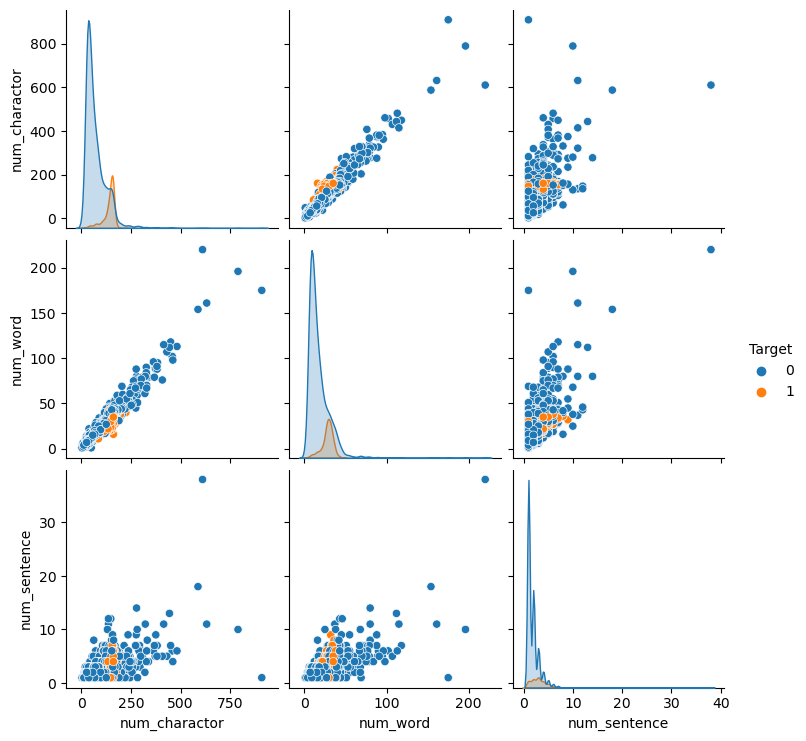

In [40]:
sns.pairplot(data,hue='Target')

In [41]:
new_data=data[['Target','num_charactor','num_word','num_sentence']]

In [42]:
new_data.corr()

,Target,num_charactor,num_word,num_sentence
Target,1.000000,0.384717,0.262912,0.263939
num_charactor,0.384717,1.000000,0.965760,0.624139
num_word,0.262912,0.965760,1.000000,0.679971
num_sentence,0.263939,0.624139,0.679971,1.000000


<Axes: >

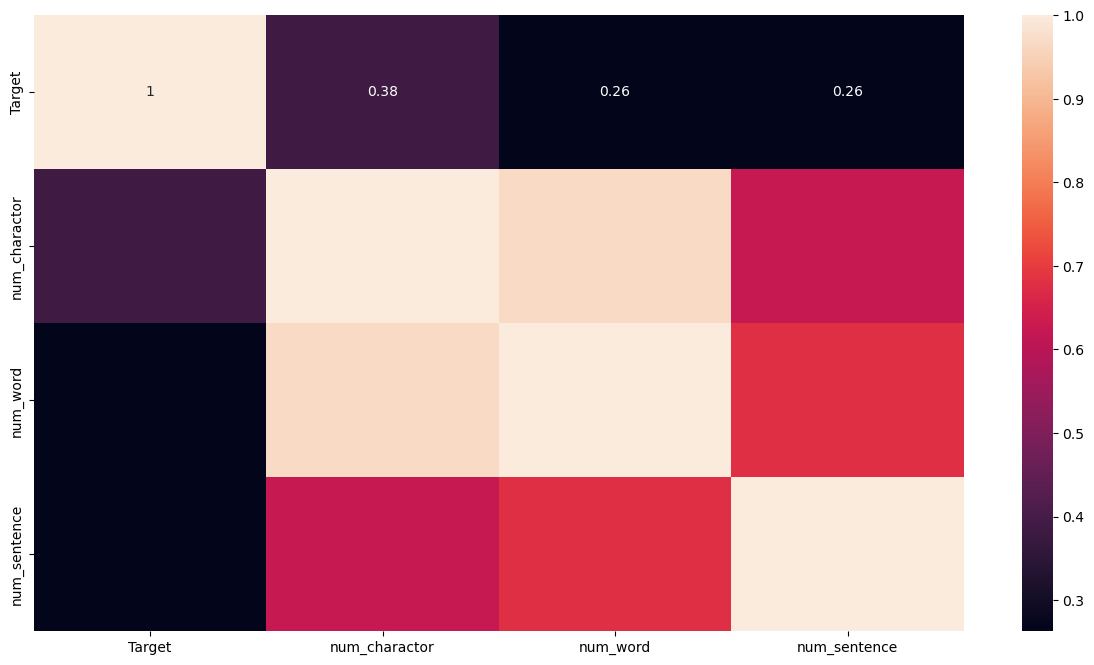

In [43]:
plt.figure(figsize=(15,8))
sns.heatmap(new_data.corr(),annot=True)

In [44]:
# Data Preprocessing
## convert Mails into lower case
## Tokanization 
# Removing spacial charactor
# removing stop word and punctuation
# steming"

<h1>Data Preprocessing</h1>

<h2>1. Convert Emails into Lowercase</h2>
<p>Convert the text to lowercase to ensure case-insensitivity.</p>
<pre><code>text = text.lower()</code></pre>

<h2>2. Tokenization</h2>
<p>Break down the text into individual words (tokens).</p>
<pre><code>tokens = word_tokenize(text)</code></pre>

<h2>3. Removing Special Characters</h2>
<p>Clean the text by removing special characters and non-alphabetic symbols.</p>
<pre><code>text = re.sub(r'[^a-zA-Z\s]', '', text)</code></pre>

<h2>4. Removing Stop Words and Punctuation</h2>
<p>Remove common words (stop words) and punctuation to reduce noise.</p>
<pre><code>tokens = [word for word in tokens if word not in stop_words and word.isalpha()]</code></pre>

<h2>5. Stemming</h2>
<p>Reduce words to their root forms to group related words together.</p>
<pre><code>tokens = [stemmer.stem(word) for word in tokens]</code></pre>


In [45]:
data.sample()

,Target,Mails,num_charactor,num_word,num_sentence
978,0,Hey you can pay. With salary de. Only &lt;#&g...,50,18,3


In [46]:
 # nltk.download('stopwords')
from nltk.corpus import stopwords
import string
# string.punctuation
# stemming
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [47]:
def Transform_Mails(text):
    text=text.lower()
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)

    text=y[:] # to copy string 
    y.clear() # clear y
    for i in text:
          #Remove stop words and Punctuation from the sentence 
        if i not in stopwords.words('english') and i not in string.punctuation: 
            y.append(i)

    text=y[:] # to copy string 
    y.clear() # clear y
    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y) # To join all the words which is return
    

    

In [48]:
Transform_Mails('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [49]:
data['Mails'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [50]:
data['Transform_Mails']=data['Mails'].apply(Transform_Mails)

In [51]:
data.head()

,Target,Mails,num_charactor,num_word,num_sentence,Transform_Mails
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [52]:
#install the wordcloud in jupiter
# !pip install wordcloud

from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=8,background_color='white')


In [53]:
spam_wc=wc.generate(data[data['Target']==1]['Transform_Mails'].str.cat(sep=" "))

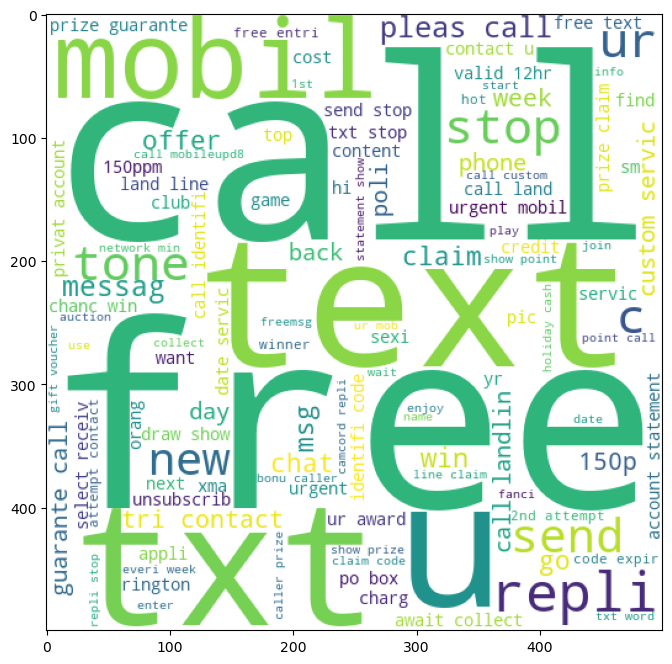

In [54]:
plt.figure(figsize=(12,8))
plt.imshow(spam_wc)

In [55]:
ham_wc=wc.generate(data[data['Target']==0]['Transform_Mails'].str.cat(sep=" "))

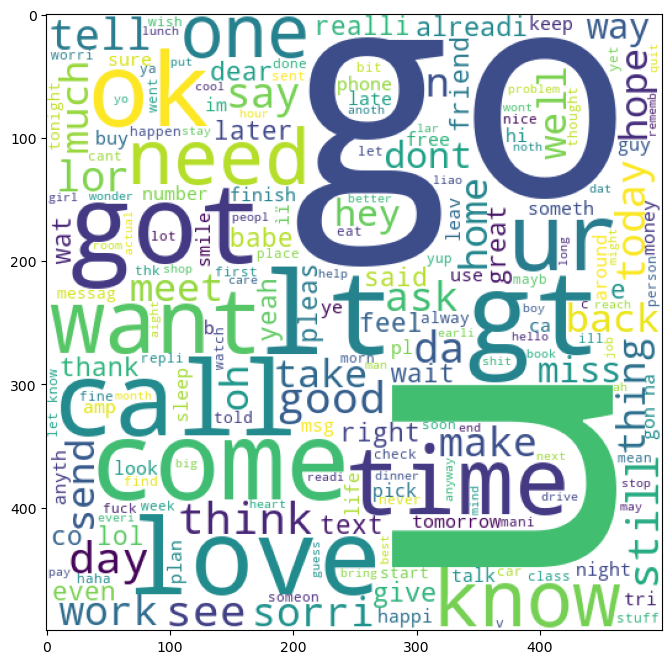

In [56]:
plt.figure(figsize=(12,8))
plt.imshow(ham_wc)

In [57]:
spam_corpus=[]
for msg in data[data['Target']==1]['Transform_Mails'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
 

In [58]:
len(spam_corpus)

9939

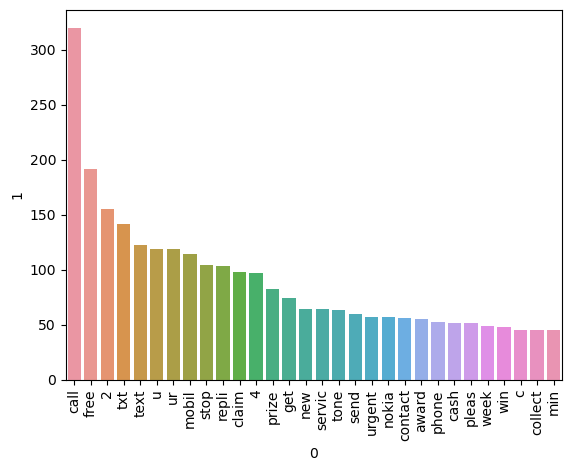

In [59]:
from collections import Counter
spam_corpus_df=pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['0', '1'])
sns.barplot(x='0', y='1', data=spam_corpus_df)
plt.xticks(rotation='vertical') # to show the Label vertical
plt.show()

In [60]:
ham_corpus=[]
for msg in data[data['Target']==0]['Transform_Mails'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [61]:
len(ham_corpus)

35404

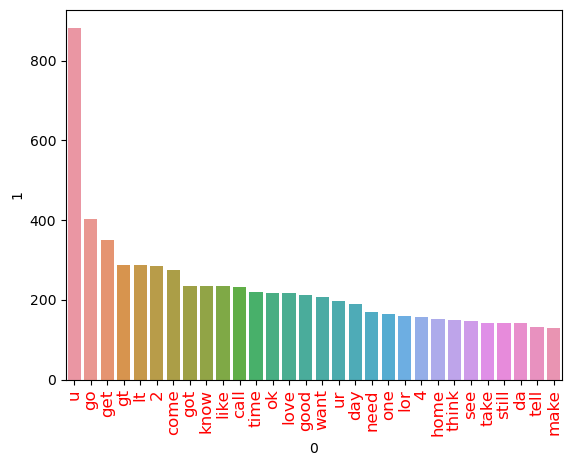

In [62]:
from collections import Counter
ham_corpus_df=pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['0', '1'])
sns.barplot(x='0', y='1', data=ham_corpus_df)
plt.xticks(rotation='vertical', fontsize=12, color='red') # to show the Label vertical
plt.show()

In [63]:
# Text visualization
#Using Bags of word
data.head()

,Target,Mails,num_charactor,num_word,num_sentence,Transform_Mails
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


# Model Building

In [64]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
Tfidf=TfidfVectorizer(max_features=3000)

In [65]:
X=Tfidf.fit_transform(data['Transform_Mails']).toarray()

In [66]:
X.shape

(5169, 3000)

In [67]:
y=data['Target'].values

In [68]:
y.shape

(5169,)

In [69]:
from sklearn.model_selection import train_test_split


In [70]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [71]:
# import the model
from sklearn.naive_bayes import BernoulliNB,GaussianNB,MultinomialNB
BNB=BernoulliNB()
GNB=GaussianNB()
MNB=MultinomialNB()

In [72]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [73]:
BNB.fit(X_train,y_train)
y_pred1=BNB.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))


0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [74]:
GNB.fit(X_train,y_train)
y_pred2=GNB.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.8694390715667312
[[788 108]
 [ 27 111]]
0.5068493150684932


In [75]:
MNB.fit(X_train,y_train)
y_pred3=MNB.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [76]:
#  the model MNB model is best for: 
print('accuracy : ',accuracy_score(y_test,y_pred3))
print('Precision : ',precision_score(y_test,y_pred3))

accuracy :  0.9709864603481625
Precision :  1.0


In [77]:
import pickle
pickle.dump(Tfidf,open('Vectorizer.pkl','wb'))
pickle.dump(MNB,open('model.pkl','wb'))

In [78]:
import nltk
print(nltk.data.path)

['C:\\Users\\SmarT TecH/nltk_data', 'C:\\soft\\anaconda3\\nltk_data', 'C:\\soft\\anaconda3\\share\\nltk_data', 'C:\\soft\\anaconda3\\lib\\nltk_data', 'C:\\Users\\SmarT TecH\\AppData\\Roaming\\nltk_data', 'C:\\nltk_data', 'D:\\nltk_data', 'E:\\nltk_data']
